# Importance Sampling for Neural Posterior Estimation

Problem 1: Normal distribution with unknown mean and variance.
$$\mu \sim \mathcal{N}(\mu_0, \sigma_0^2), \quad \sigma \sim \mathcal{U}(0, A)$$

The baseline estimator struggles with small $\sigma$ because uniform sampling rarely produces them. We fix this with importance sampling.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as nnf

class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim, n_layers=2):
        super(MLP, self).__init__()
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())
        for _ in range(n_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.nn = nn.Sequential(*layers)

    def forward(self, x):
        return self.nn(x)

class PosteriorMeanEstimator(nn.Module):
    def __init__(self, summary_stats=32, summary_width=32, estimator_width=32):
        super().__init__()
        self.mlp_point = MLP(1, summary_stats, summary_width, n_layers=2)
        self.mlp_aggregate = MLP(summary_stats, 2, estimator_width, n_layers=2)

    def forward(self, x):
        x = x.unsqueeze(-1).float()
        summaries = self.mlp_point(x)
        H = summaries.sum(dim=1)
        out = self.mlp_aggregate(H)
        mu_hat = out[:, 0]
        sigma_hat = nnf.softplus(out[:, 1])
        return torch.stack([mu_hat, sigma_hat], dim=1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Setup

In [2]:
sigma0 = 1
mu0 = 0
A = 5
n = 64

n_epochs = 64
n_batches_per_epoch = 128
training_batch_size = 128
lr = 1e-4

# Fixed test set sampled from the TRUE prior (uniform sigma)
np.random.seed(42)
test_size = 2048
mu_test = np.random.normal(mu0, sigma0, size=test_size)
sigma_test = np.random.uniform(0, A, size=test_size)
x_test_np = np.array([np.random.normal(mu_test[i], sigma_test[i], size=n) for i in range(test_size)])

x_test = torch.tensor(x_test_np, dtype=torch.float32).to(device)
theta_test = torch.tensor(np.stack([mu_test, sigma_test], axis=1), dtype=torch.float32).to(device)

loss_fn = nn.MSELoss()

## Sampling functions

In [3]:
def sample_batch_uniform(batch_size):
    """Sample from the true prior: sigma ~ Uniform(0, A)"""
    mu = np.random.normal(mu0, sigma0, size=batch_size)
    sigma = np.random.uniform(0, A, size=batch_size)
    x = np.array([np.random.normal(mu[i], sigma[i], size=n) for i in range(batch_size)])
    theta = torch.tensor(np.stack([mu, sigma], axis=1), dtype=torch.float32)
    x = torch.tensor(x, dtype=torch.float32)
    return theta, x


def sample_batch_IS(batch_size, alpha, beta_param):
    """Sample sigma from Beta proposal scaled to [0, A], with correct IS weights."""
    mu = np.random.normal(mu0, sigma0, size=batch_size)
    
    # sigma_tilde ~ Beta(alpha, beta_param), then sigma = A * sigma_tilde
    sigma_tilde = np.random.beta(alpha, beta_param, size=batch_size)
    sigma = A * sigma_tilde
    
    x = np.array([np.random.normal(mu[i], sigma[i], size=n) for i in range(batch_size)])
    
    # Importance weights: w = p(sigma) / q(sigma)
    # p(sigma) = 1/A  (uniform on [0, A])
    # q(sigma) = Beta(sigma/A; alpha, beta_param) / A
    # w = (1/A) / (Beta(sigma/A; alpha, beta_param) / A) = 1 / Beta(sigma/A; alpha, beta_param)
    q_vals = stats.beta.pdf(sigma_tilde, alpha, beta_param)
    weights = 1.0 / q_vals
    
    theta = torch.tensor(np.stack([mu, sigma], axis=1), dtype=torch.float32)
    x = torch.tensor(x, dtype=torch.float32)
    weights = torch.tensor(weights, dtype=torch.float32)
    
    return theta, x, weights

## Visualise proposal distributions

Before training, let's see what different Beta proposals look like and how their weights behave.

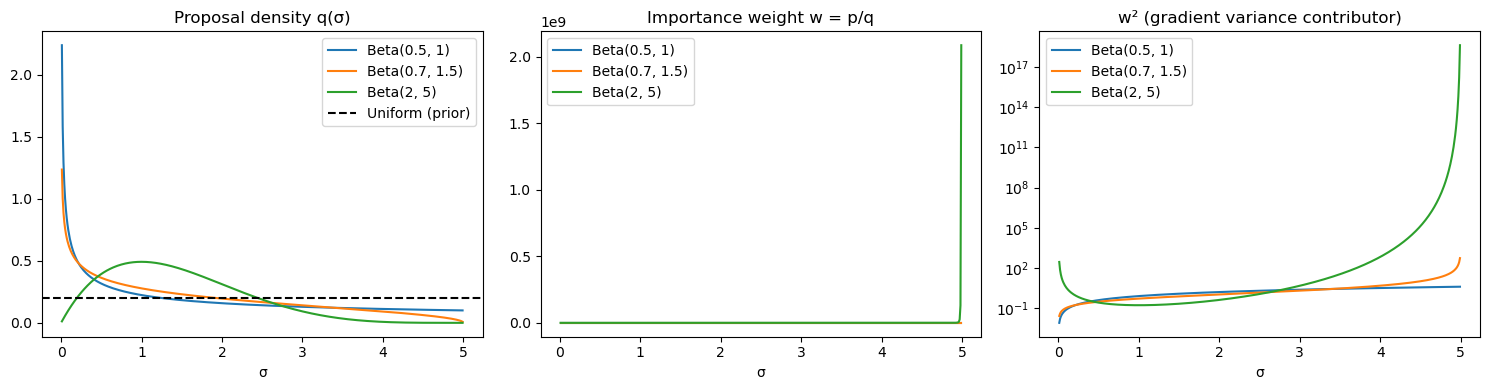

Max weight w for each proposal:
  Beta(0.5, 1): max w = 2.0
  Beta(0.7, 1.5): max w = 23.3
  Beta(2, 5): max w = 2087508350.0


In [4]:
proposals = [
    (0.5, 1.0, 'Beta(0.5, 1)'),
    (0.7, 1.5, 'Beta(0.7, 1.5)'),
    (2.0, 5.0, 'Beta(2, 5)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sigma_grid = np.linspace(0.01, A - 0.01, 500)
sigma_tilde_grid = sigma_grid / A

for alpha, beta_param, label in proposals:
    q_density = stats.beta.pdf(sigma_tilde_grid, alpha, beta_param) / A
    p_density = np.ones_like(sigma_grid) / A
    w = p_density / q_density
    
    axes[0].plot(sigma_grid, q_density, label=label)
    axes[1].plot(sigma_grid, w, label=label)
    axes[2].plot(sigma_grid, w**2, label=label)

axes[0].axhline(1/A, color='k', ls='--', label='Uniform (prior)')
axes[0].set_title('Proposal density q(σ)')
axes[0].set_xlabel('σ'); axes[0].legend()

axes[1].set_title('Importance weight w = p/q')
axes[1].set_xlabel('σ'); axes[1].legend()

axes[2].set_title('w² (gradient variance contributor)')
axes[2].set_xlabel('σ'); axes[2].set_yscale('log'); axes[2].legend()

plt.tight_layout()
plt.show()

print("Max weight w for each proposal:")
for alpha, beta_param, label in proposals:
    w = 1.0 / stats.beta.pdf(sigma_tilde_grid, alpha, beta_param)
    print(f"  {label}: max w = {w.max():.1f}")

## Training

In [5]:
def train_baseline(seed=0):
    """Train with uniform sampling (standard MSE loss)."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = PosteriorMeanEstimator().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    test_losses = []

    for epoch in range(n_epochs):
        for _ in range(n_batches_per_epoch):
            theta_batch, x_batch = sample_batch_uniform(training_batch_size)
            x_batch, theta_batch = x_batch.to(device), theta_batch.to(device)

            optimizer.zero_grad()
            pred = model(x_batch)
            loss = loss_fn(pred, theta_batch)
            loss.backward()
            optimizer.step()

        with torch.no_grad():
            test_losses.append(loss_fn(model(x_test), theta_test).item())
        if (epoch + 1) % 16 == 0:
            print(f"  Baseline epoch {epoch+1}/{n_epochs}, Test MSE: {test_losses[-1]:.4f}")

    return model, test_losses


def train_IS(alpha, beta_param, seed=0, clip_weights=None):
    """Train with IS proposal, self-normalized weighted MSE loss."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = PosteriorMeanEstimator().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    test_losses = []

    for epoch in range(n_epochs):
        for _ in range(n_batches_per_epoch):
            theta_batch, x_batch, weights = sample_batch_IS(training_batch_size, alpha, beta_param)
            x_batch, theta_batch = x_batch.to(device), theta_batch.to(device)
            weights = weights.to(device)

            # Clip extreme weights to stabilise training
            if clip_weights is not None:
                weights = weights.clamp(max=clip_weights)

            optimizer.zero_grad()
            pred = model(x_batch)
            sq_err = ((pred - theta_batch) ** 2).sum(dim=1)

            # Self-normalized IS: sum(w_i * L_i) / sum(w_i)
            loss = (weights * sq_err).sum() / weights.sum()
            loss.backward()
            optimizer.step()

        with torch.no_grad():
            test_losses.append(loss_fn(model(x_test), theta_test).item())
        if (epoch + 1) % 16 == 0:
            print(f"  IS({alpha},{beta_param}) epoch {epoch+1}/{n_epochs}, Test MSE: {test_losses[-1]:.4f}")

    return model, test_losses

In [6]:
print("Training baseline...")
model_base, losses_base = train_baseline(seed=0)

print("\nTraining IS with Beta(0.5, 1)...")
model_is1, losses_is1 = train_IS(0.5, 1.0, seed=0)

print("\nTraining IS with Beta(0.7, 1.5)...")
model_is2, losses_is2 = train_IS(0.7, 1.5, seed=0)

print("\nTraining IS with Beta(2, 5) + weight clipping...")
model_is3, losses_is3 = train_IS(2.0, 5.0, seed=0, clip_weights=10.0)

Training baseline...
  Baseline epoch 16/64, Test MSE: 0.0936
  Baseline epoch 32/64, Test MSE: 0.0889
  Baseline epoch 48/64, Test MSE: 0.0857
  Baseline epoch 64/64, Test MSE: 0.0846

Training IS with Beta(0.5, 1)...
  IS(0.5,1.0) epoch 16/64, Test MSE: 0.0922
  IS(0.5,1.0) epoch 32/64, Test MSE: 0.0870
  IS(0.5,1.0) epoch 48/64, Test MSE: 0.0862
  IS(0.5,1.0) epoch 64/64, Test MSE: 0.0855

Training IS with Beta(0.7, 1.5)...
  IS(0.7,1.5) epoch 16/64, Test MSE: 0.0990
  IS(0.7,1.5) epoch 32/64, Test MSE: 0.0890
  IS(0.7,1.5) epoch 48/64, Test MSE: 0.0875
  IS(0.7,1.5) epoch 64/64, Test MSE: 0.0856

Training IS with Beta(2, 5) + weight clipping...
  IS(2.0,5.0) epoch 16/64, Test MSE: 0.1018
  IS(2.0,5.0) epoch 32/64, Test MSE: 0.1016
  IS(2.0,5.0) epoch 48/64, Test MSE: 0.1034
  IS(2.0,5.0) epoch 64/64, Test MSE: 0.0986


## Test loss curves

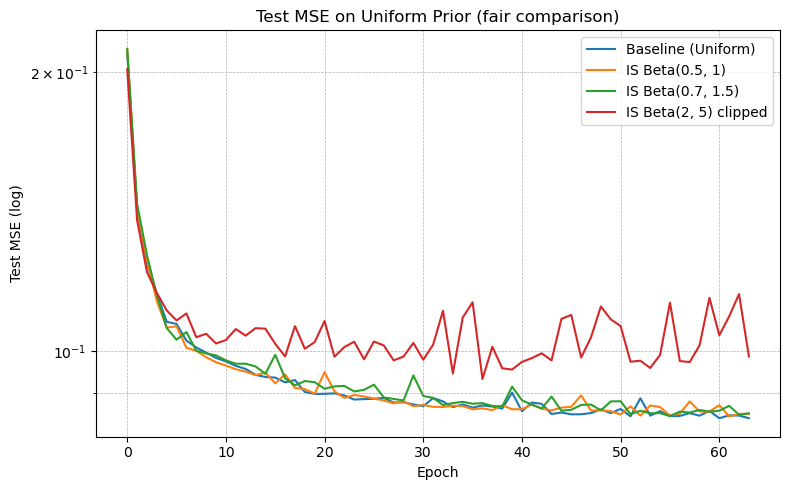

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(losses_base, label='Baseline (Uniform)')
plt.plot(losses_is1, label='IS Beta(0.5, 1)')
plt.plot(losses_is2, label='IS Beta(0.7, 1.5)')
plt.plot(losses_is3, label='IS Beta(2, 5) clipped')
plt.yscale('log')
plt.xlabel('Epoch'); plt.ylabel('Test MSE (log)')
plt.title('Test MSE on Uniform Prior (fair comparison)')
plt.legend(); plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout(); plt.show()

## MSE breakdown by sigma bin

This is the key diagnostic — the whole point is to check whether IS helps in the small-sigma regime.

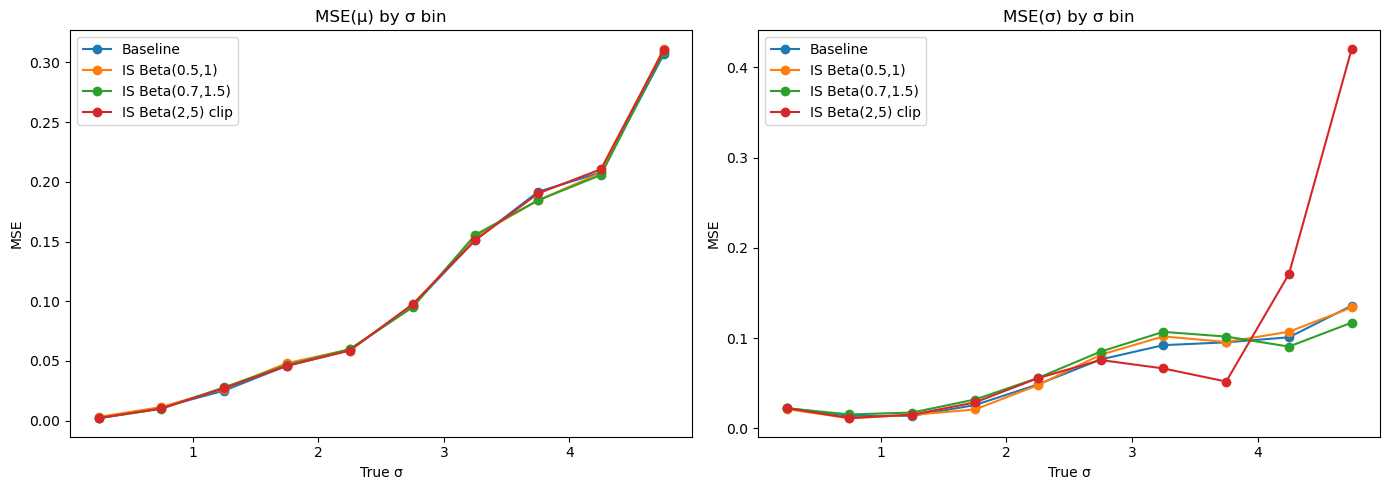

In [8]:
def compute_binned_mse(model, x_test, theta_test, n_bins=10):
    """Compute MSE for mu and sigma in bins of true sigma."""
    with torch.no_grad():
        pred = model(x_test).cpu().numpy()
    true = theta_test.cpu().numpy()
    
    sigma_true = true[:, 1]
    bin_edges = np.linspace(0, A, n_bins + 1)
    bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    mse_mu = np.zeros(n_bins)
    mse_sigma = np.zeros(n_bins)
    counts = np.zeros(n_bins)
    
    for b in range(n_bins):
        mask = (sigma_true >= bin_edges[b]) & (sigma_true < bin_edges[b+1])
        if mask.sum() == 0:
            continue
        counts[b] = mask.sum()
        mse_mu[b] = np.mean((pred[mask, 0] - true[mask, 0])**2)
        mse_sigma[b] = np.mean((pred[mask, 1] - true[mask, 1])**2)
    
    return bin_centres, mse_mu, mse_sigma, counts


models = {
    'Baseline': model_base,
    'IS Beta(0.5,1)': model_is1,
    'IS Beta(0.7,1.5)': model_is2,
    'IS Beta(2,5) clip': model_is3,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, model in models.items():
    centres, mse_mu, mse_sig, counts = compute_binned_mse(model, x_test, theta_test)
    axes[0].plot(centres, mse_mu, 'o-', label=name)
    axes[1].plot(centres, mse_sig, 'o-', label=name)

axes[0].set_xlabel('True σ'); axes[0].set_ylabel('MSE')
axes[0].set_title('MSE(μ) by σ bin'); axes[0].legend()
axes[1].set_xlabel('True σ'); axes[1].set_ylabel('MSE')
axes[1].set_title('MSE(σ) by σ bin'); axes[1].legend()
plt.tight_layout(); plt.show()

## Overall MSE comparison table

In [9]:
print(f"{'Model':25s} {'MSE(μ)':>10s} {'MSE(σ)':>10s} {'Total':>10s}")
print('-' * 57)

for name, model in models.items():
    with torch.no_grad():
        pred = model(x_test).cpu().numpy()
    true = theta_test.cpu().numpy()
    mse_mu = np.mean((pred[:, 0] - true[:, 0])**2)
    mse_sig = np.mean((pred[:, 1] - true[:, 1])**2)
    print(f"{name:25s} {mse_mu:10.4f} {mse_sig:10.4f} {mse_mu + mse_sig:10.4f}")

Model                         MSE(μ)     MSE(σ)      Total
---------------------------------------------------------
Baseline                      0.1075     0.0617     0.1692
IS Beta(0.5,1)                0.1081     0.0629     0.1710
IS Beta(0.7,1.5)              0.1074     0.0638     0.1712
IS Beta(2,5) clip             0.1082     0.0890     0.1972


## Scatter plots: baseline vs best IS

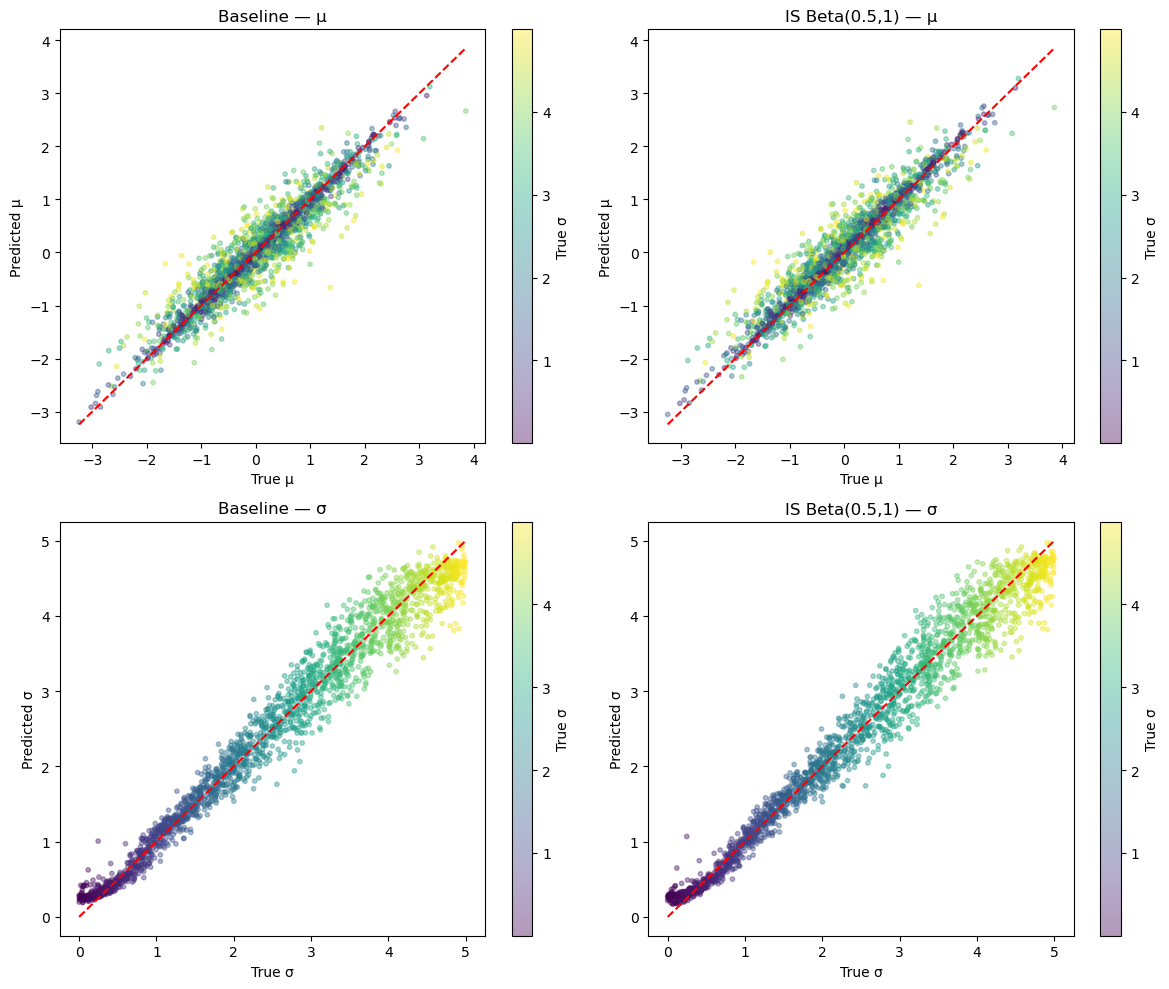

In [10]:
with torch.no_grad():
    pred_base = model_base(x_test).cpu().numpy()
    pred_best = model_is1(x_test).cpu().numpy()
true = theta_test.cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for col, (name, pred) in enumerate([('Baseline', pred_base), ('IS Beta(0.5,1)', pred_best)]):
    sc = axes[0, col].scatter(true[:, 0], pred[:, 0], c=true[:, 1], alpha=0.4, s=10, cmap='viridis')
    axes[0, col].plot([true[:, 0].min(), true[:, 0].max()],
                      [true[:, 0].min(), true[:, 0].max()], 'r--')
    axes[0, col].set_xlabel('True μ'); axes[0, col].set_ylabel('Predicted μ')
    axes[0, col].set_title(f'{name} — μ')
    plt.colorbar(sc, ax=axes[0, col], label='True σ')

    sc = axes[1, col].scatter(true[:, 1], pred[:, 1], c=true[:, 1], alpha=0.4, s=10, cmap='viridis')
    axes[1, col].plot([0, A], [0, A], 'r--')
    axes[1, col].set_xlabel('True σ'); axes[1, col].set_ylabel('Predicted σ')
    axes[1, col].set_title(f'{name} — σ')
    plt.colorbar(sc, ax=axes[1, col], label='True σ')

plt.tight_layout(); plt.show()